In [36]:
import matplotlib.pyplot as plt
import pandas as pd

=============================
LOAD AND PREPARE DATA
=============================

In [37]:
def load_data(filename):
    """
    Loads the Spotify CSV and returns a cleaned DataFrame.
    """
    df = pd.read_csv(filename)

    df["primary_genre"] = df["genre"].str.split(",").str[0].str.strip()

    df["decade"] = (df["year"] // 10) * 10

    return df

In [38]:
def display_audio_features_by_genre(df):
    # Step 1: Find the 8 most common genres
    top_genres = df["primary_genre"].value_counts().head(8).index

    # Step 2: Filter the dateframe to only those 8 selected genres
    df_top = df[df["primary_genre"].isin(top_genres)]

    genre_means = df_top.groupby("primary_genre")[["danceability", "energy", "valence"]].mean()

    fig, ax = plt.subplots(figsize=(12,6))

    genre_means.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c", "#2ecc71"])

    ax.set_title("Average Audio Features by Genre", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Genre")
    ax.set_ylabel("Average Score")
    ax.legend(title="Features", fontsize=10)

    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()

    plt.savefig("spotify_visualization.png")

    plt.show()

    print("\n")
    print("Genre Means")
    print(genre_means)

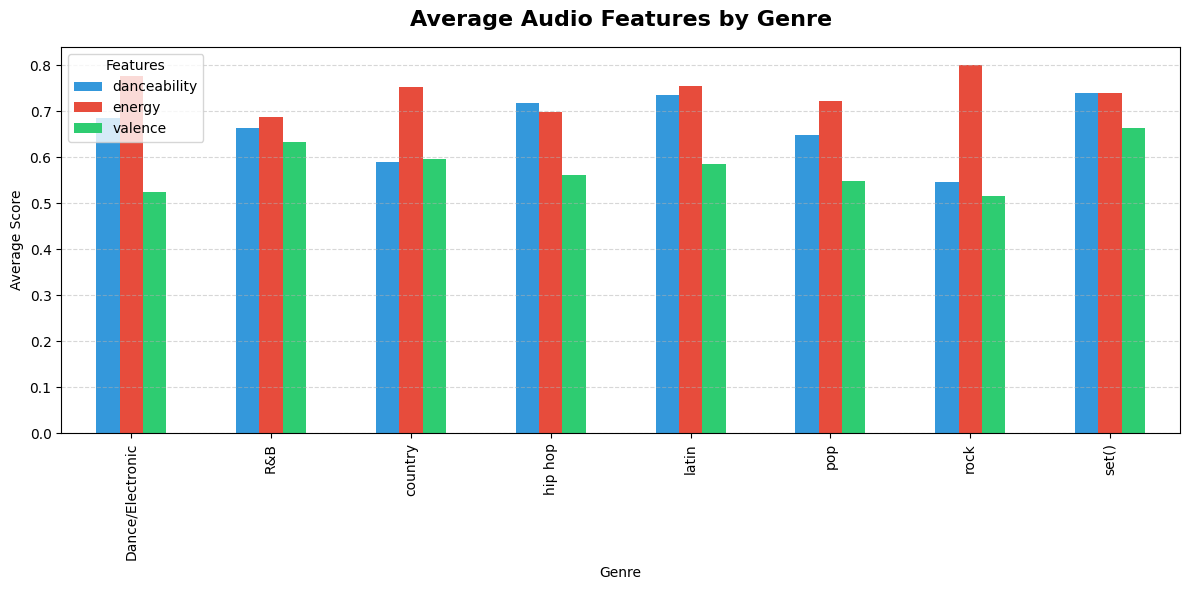



Genre Means
                  danceability    energy   valence
primary_genre                                     
Dance/Electronic      0.684610  0.775829  0.523585
R&B                   0.663462  0.688077  0.633308
country               0.588545  0.751545  0.596818
hip hop               0.717843  0.698778  0.560668
latin                 0.734800  0.753600  0.584067
pop                   0.647753  0.721256  0.547501
rock                  0.545216  0.799673  0.516181
set()                 0.739000  0.738955  0.663273


In [39]:
spotify_df = load_data("../../data/spotify_top_hits_2000_2009.csv")

display_audio_features_by_genre(spotify_df)